In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("✓ Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


✓ Libraries loaded successfully


In [2]:
print("Loading dataset...")
df = pd.read_csv('../data/raw/dataset.csv')

print(f"\n✓ Dataset loaded!")
print(f"Total samples: {len(df):,}")
print(f"Total columns: {len(df.columns)}")

Loading dataset...

✓ Dataset loaded!
Total samples: 709,582
Total columns: 26


In [3]:
print("Column names:")
print(list(df.columns))

print("\nFirst 5 rows:")
df.head()

Column names:
['Activity', 'Ax_p', 'Ax_w', 'Ay_p', 'Ay_w', 'Az_p', 'Az_w', 'GPS1_p', 'GPS2_p', 'Gx_p', 'Gx_w', 'Gy_p', 'Gy_w', 'Gz_p', 'Gz_w', 'Mx_p', 'Mx_w', 'My_p', 'My_w', 'Mz_p', 'Mz_w', 'PocketDev', 'Time_p', 'Time_w', 'User', 'WristDev']

First 5 rows:


,Activity,Ax_p,Ax_w,Ay_p,Ay_w,Az_p,Az_w,GPS1_p,GPS2_p,Gx_p,...,Mx_w,My_p,My_w,Mz_p,Mz_w,PocketDev,Time_p,Time_w,User,WristDev
0,knuckles_cracking,-1.127655,0.77,-2.090134,-0.45,9.476257,-0.34,0.0,0.0,-0.001160,...,-100.98,-45.750427,-58.96,-163.04932,-22.21,S8,1.557220e+12,3392.0,3,SF1
1,knuckles_cracking,-1.127655,0.76,-2.090134,-0.44,9.476257,-0.36,0.0,0.0,-0.003830,...,-100.98,-46.949768,-58.96,-162.15057,-22.21,S8,1.557220e+12,3401.0,3,SF1
2,knuckles_cracking,-1.120483,0.74,-2.075775,-0.43,9.519363,-0.35,0.0,0.0,-0.005508,...,-100.98,-46.800232,-58.96,-161.54938,-22.21,S8,1.557220e+12,3420.0,3,SF1
3,knuckles_cracking,-1.113296,0.74,-2.061401,-0.40,9.533722,-0.38,0.0,0.0,-0.005493,...,-100.98,-46.949768,-58.96,-162.15057,-22.21,S8,1.557220e+12,3440.0,3,SF1
4,knuckles_cracking,-1.120483,0.74,-2.047043,-0.43,9.526535,-0.39,0.0,0.0,-0.005798,...,-100.68,-46.800232,-59.41,-164.54926,-19.20,S8,1.557220e+12,3460.0,3,SF1


In [4]:
print("="*60)
print("ACTIVITY DISTRIBUTION")
print("="*60)

activities = df['Activity'].value_counts()
print(activities)

print(f"\nTotal unique activities: {len(activities)}")

ACTIVITY DISTRIBUTION
Activity
nape_rubbing         67859
knuckles_cracking    67498
smoking              66937
ear_rubbing          66599
hair_pulling         65973
forehead_rubbing     64604
hand_scratching      64490
nail_biting          63457
hand_tapping         63220
sitting              59996
standing             58949
Name: count, dtype: int64

Total unique activities: 11


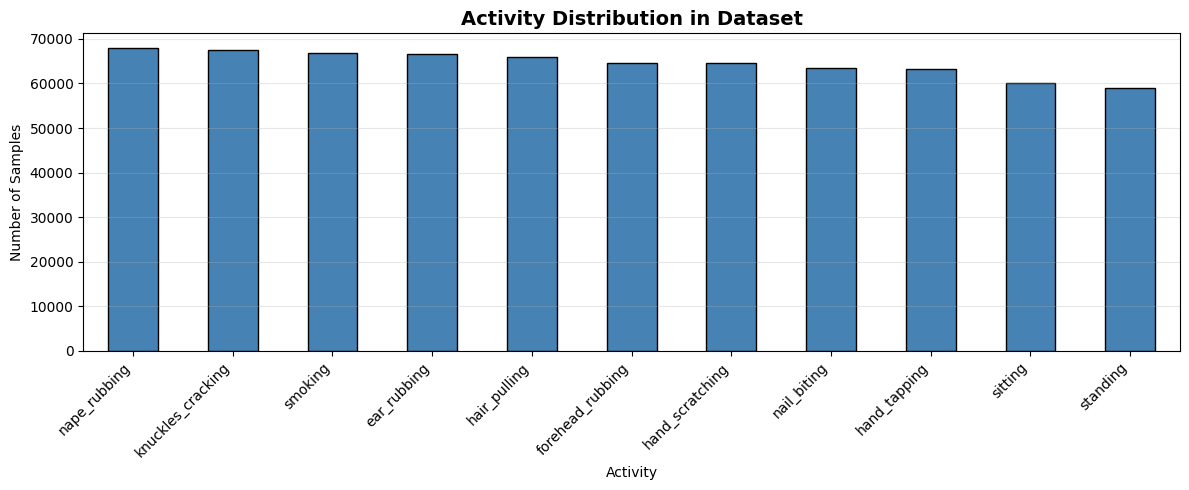

In [5]:
plt.figure(figsize=(12, 5))
activities.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Activity Distribution in Dataset', fontsize=14, weight='bold')
plt.xlabel('Activity')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
print("="*60)
print("SAMPLING RATE CALCULATION")
print("="*60)

# Calculate time differences
time_diffs = np.diff(df['Time_w'].values)
time_diffs = time_diffs[time_diffs > 0]  # Remove zeros

avg_interval = np.mean(time_diffs)
median_interval = np.median(time_diffs)

# Determine if milliseconds or other unit
if avg_interval > 100:
    sampling_rate = 1000 / avg_interval  # milliseconds
    unit = "milliseconds"
else:
    sampling_rate = 1 / avg_interval  # seconds
    unit = "seconds"

print(f"Average time interval: {avg_interval:.2f} {unit}")
print(f"Median time interval: {median_interval:.2f} {unit}")
print(f"Estimated sampling rate: {sampling_rate:.2f} Hz")

SAMPLING RATE CALCULATION
Average time interval: 20.00 seconds
Median time interval: 20.00 seconds
Estimated sampling rate: 0.05 Hz


In [7]:
print("="*60)
print("WRIST SENSOR STATISTICS")
print("="*60)

wrist_cols = ['Ax_w', 'Ay_w', 'Az_w', 'Gx_w', 'Gy_w', 'Gz_w']
sensor_stats = df[wrist_cols].describe()

print(sensor_stats)

WRIST SENSOR STATISTICS
                Ax_w           Ay_w           Az_w           Gx_w  \
count  709582.000000  709582.000000  709582.000000  709582.000000   
mean        0.226767       0.058069      -0.457419      -0.910414   
std         0.580315       0.498884       0.389257      48.462206   
min        -2.000000      -2.000000      -2.000000    -786.160000   
25%        -0.100000      -0.280000      -0.820000     -10.910000   
50%         0.220000       0.000000      -0.440000      -0.730000   
75%         0.780000       0.450000      -0.150000       8.410000   
max         2.000000       2.000000       2.000000     783.350000   

                Gy_w           Gz_w  
count  709582.000000  709582.000000  
mean        1.728347       0.077569  
std        23.685636      20.974970  
min      -401.950000    -508.900000  
25%        -2.930000      -4.270000  
50%         1.710000       0.060000  
75%         7.560000       4.330000  
max       439.270000     572.010000  


In [8]:
print("="*60)
print("USER DISTRIBUTION")
print("="*60)

user_counts = df['User'].value_counts().sort_index()
print(f"Total users: {len(user_counts)}")
print("\nSamples per user:")
print(user_counts)

USER DISTRIBUTION
Total users: 10

Samples per user:
User
2      66162
3      60725
5      52447
6      61477
7      68480
8      61014
10     69274
14     67304
15     66293
16    136406
Name: count, dtype: int64


Plotting Accelerometer data...


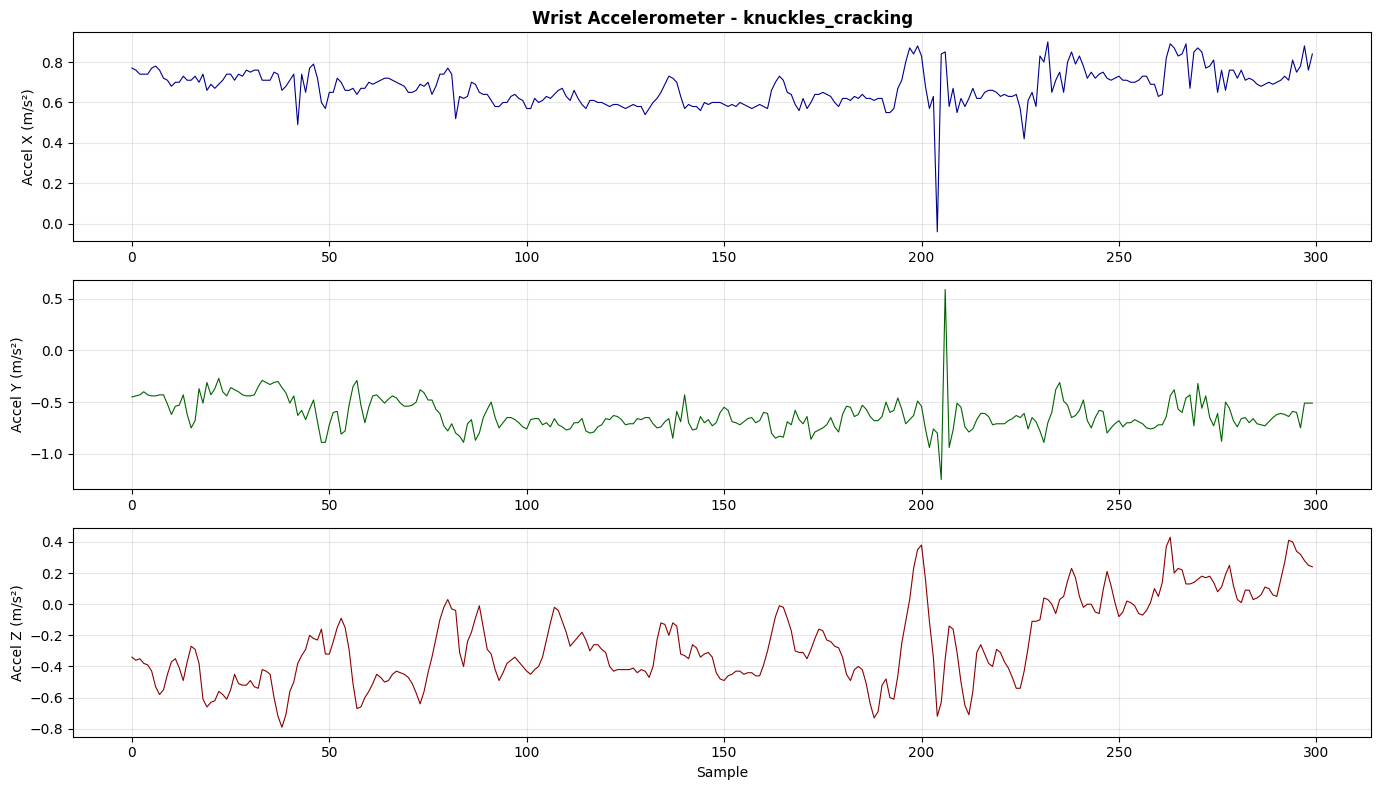

In [9]:
print("Plotting Accelerometer data...")

# Select first activity
first_activity = df['Activity'].iloc[0]
activity_data = df[df['Activity'] == first_activity].head(300)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(activity_data['Ax_w'].values, color='darkblue', linewidth=0.8)
axes[0].set_ylabel('Accel X (m/s²)')
axes[0].set_title(f'Wrist Accelerometer - {first_activity}', fontsize=12, weight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(activity_data['Ay_w'].values, color='darkgreen', linewidth=0.8)
axes[1].set_ylabel('Accel Y (m/s²)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(activity_data['Az_w'].values, color='darkred', linewidth=0.8)
axes[2].set_ylabel('Accel Z (m/s²)')
axes[2].set_xlabel('Sample')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Plotting Gyroscope data...


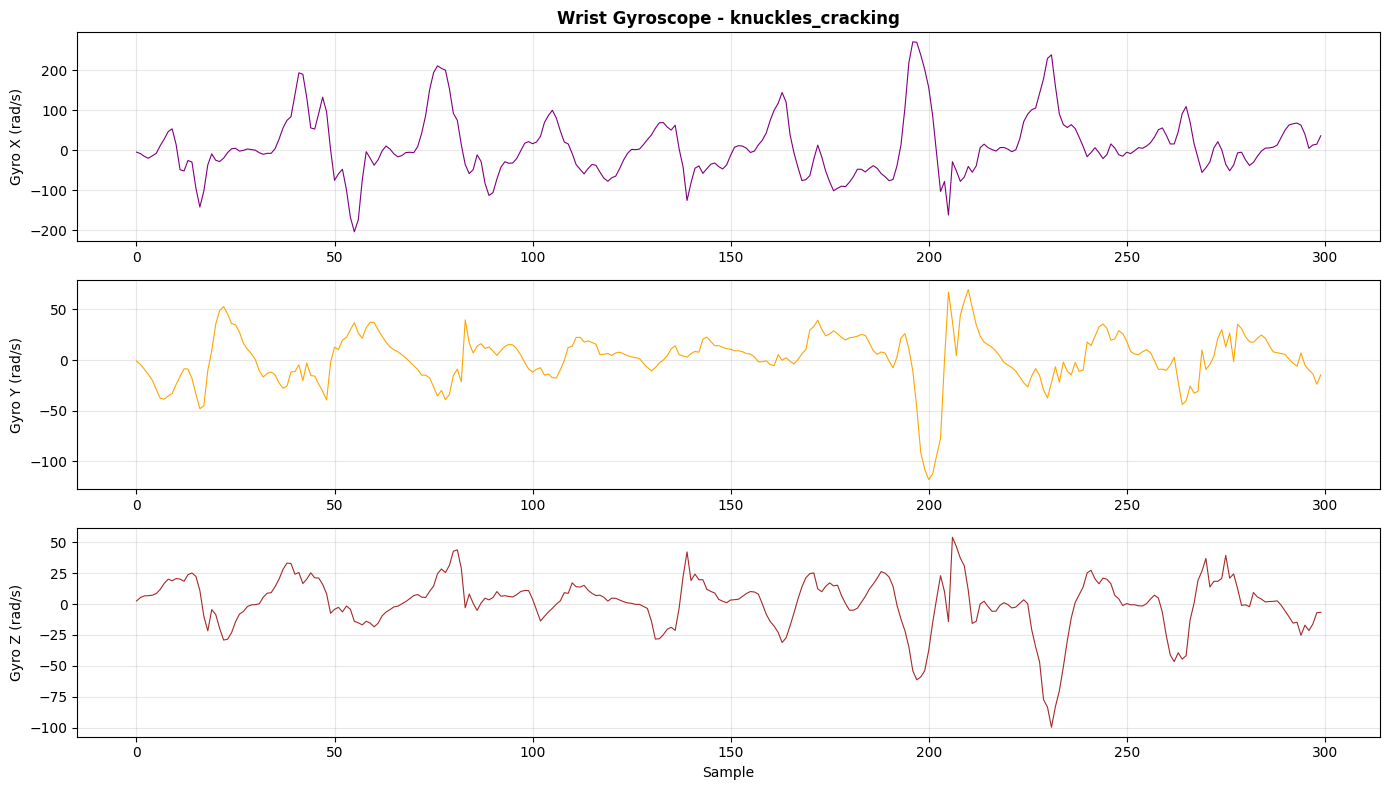

In [10]:
print("Plotting Gyroscope data...")

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(activity_data['Gx_w'].values, color='purple', linewidth=0.8)
axes[0].set_ylabel('Gyro X (rad/s)')
axes[0].set_title(f'Wrist Gyroscope - {first_activity}', fontsize=12, weight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(activity_data['Gy_w'].values, color='orange', linewidth=0.8)
axes[1].set_ylabel('Gyro Y (rad/s)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(activity_data['Gz_w'].values, color='brown', linewidth=0.8)
axes[2].set_ylabel('Gyro Z (rad/s)')
axes[2].set_xlabel('Sample')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Comparing different activities...


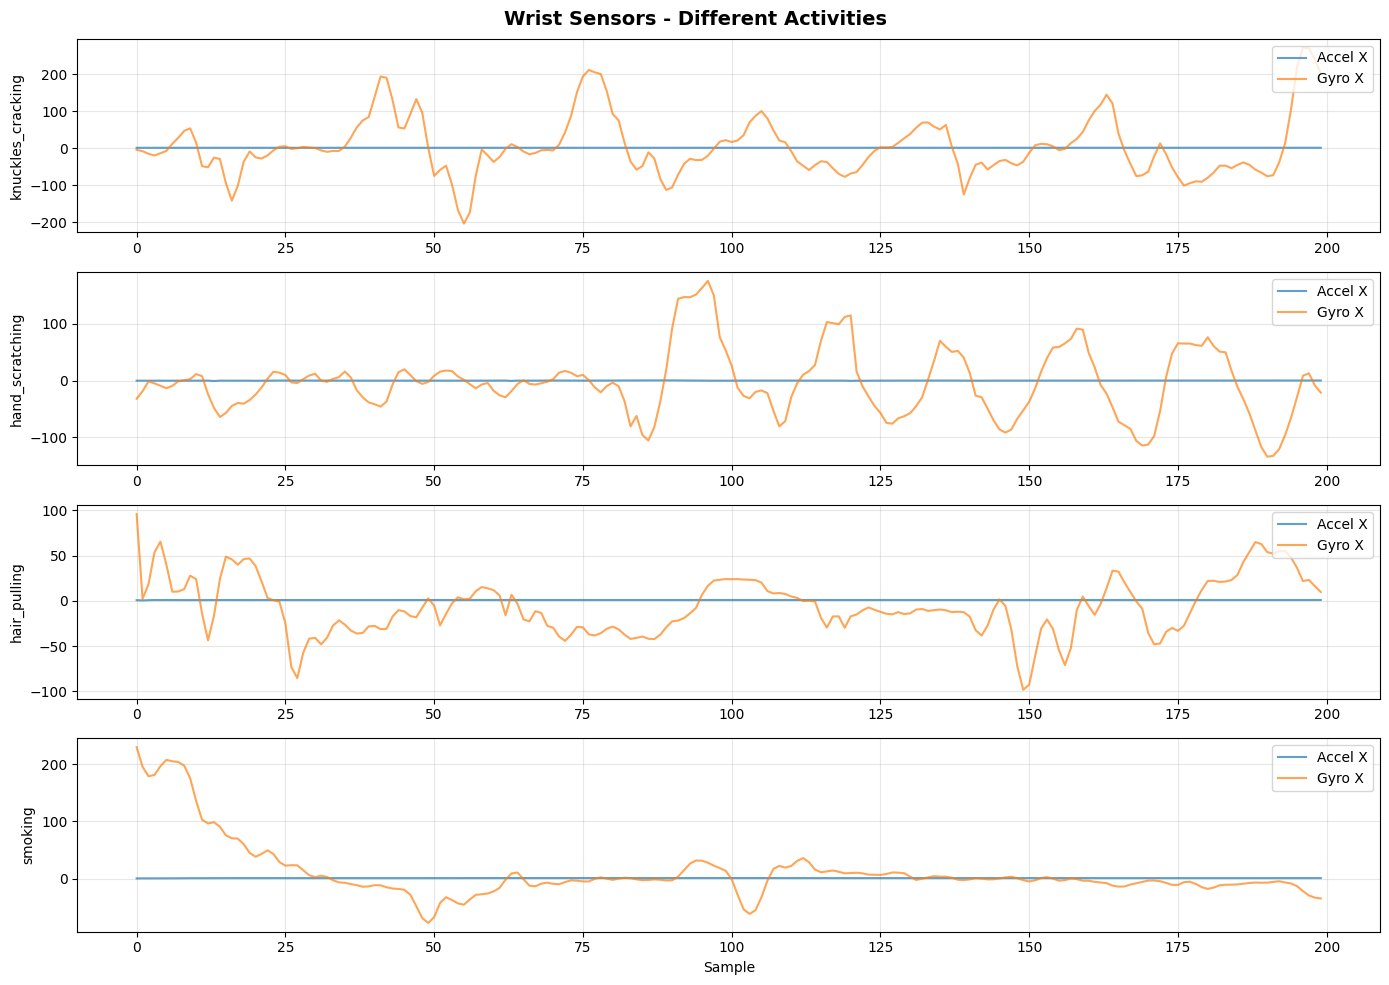

In [11]:
print("Comparing different activities...")

# Select 4 different activities
unique_activities = df['Activity'].unique()[:4]

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

for i, activity in enumerate(unique_activities):
    activity_data = df[df['Activity'] == activity].head(200)
    axes[i].plot(activity_data['Ax_w'].values, label='Accel X', alpha=0.7)
    axes[i].plot(activity_data['Gx_w'].values, label='Gyro X', alpha=0.7)
    axes[i].set_ylabel(activity)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Sample')
plt.suptitle('Wrist Sensors - Different Activities', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [14]:
print("="*60)
print("SAMPLING RATE CALCULATION (FIXED)")
print("="*60)

# Use the FIRST activity whatever it is
first_activity = df['Activity'].iloc[0]
print(f"Using activity: {first_activity}")

# Get data for one user and one activity
sample_data = df[(df['User'] == 1) & (df['Activity'] == first_activity)].head(200)

if len(sample_data) == 0:
    # Try without user filter
    print("No data for User 1, trying all users...")
    sample_data = df[df['Activity'] == first_activity].head(200)

print(f"Sample data size: {len(sample_data)}")

if len(sample_data) > 1:
    # Calculate differences
    time_values = sample_data['Time_w'].values
    print(f"\nFirst 10 time values:\n{time_values[:10]}")
    
    time_diffs = np.diff(time_values)
    print(f"\nFirst 10 time differences:\n{time_diffs[:10]}")
    
    # Remove zeros and outliers
    valid_diffs = time_diffs[time_diffs > 0]
    
    if len(valid_diffs) > 0:
        print(f"\nValid differences count: {len(valid_diffs)}")
        print(f"Min diff: {valid_diffs.min():.2f}")
        print(f"Max diff: {valid_diffs.max():.2f}")
        print(f"Mean diff: {valid_diffs.mean():.2f}")
        print(f"Median diff: {np.median(valid_diffs):.2f}")
        
        # Looking at your first timestamps: 3392, 3401, 3420...
        # Differences are: 9, 19, 20, 20...
        # These look like they're in milliseconds
        
        # Calculate sampling rate
        mean_interval = valid_diffs.mean()
        
        if mean_interval > 1000:
            # Milliseconds → Hz
            sampling_rate = 1000 / mean_interval
            unit = "milliseconds"
        elif mean_interval >= 10:
            # Likely milliseconds (10-20ms = 50-100Hz)
            sampling_rate = 1000 / mean_interval
            unit = "milliseconds"
        elif mean_interval >= 1:
            # Seconds
            sampling_rate = 1 / mean_interval
            unit = "seconds"
        else:
            # Very small, likely microseconds
            sampling_rate = 1000000 / mean_interval
            unit = "microseconds"
        
        print(f"\nUnit: {unit}")
        print(f"\n{'='*60}")
        print(f"ESTIMATED SAMPLING RATE: {sampling_rate:.2f} Hz")
        print(f"{'='*60}")
        
        # Calculate recommended window size
        window_size_2s = int(sampling_rate * 2)
        window_size_2_5s = int(sampling_rate * 2.5)
        window_size_3s = int(sampling_rate * 3)
        
        print(f"\nRecommended window sizes:")
        print(f"  2.0 seconds = {window_size_2s} samples")
        print(f"  2.5 seconds = {window_size_2_5s} samples")
        print(f"  3.0 seconds = {window_size_3s} samples")
    else:
        print("ERROR: No valid time differences found!")
else:
    print("ERROR: Not enough sample data!")

SAMPLING RATE CALCULATION (FIXED)
Using activity: knuckles_cracking
No data for User 1, trying all users...
Sample data size: 200

First 10 time values:
[3392. 3401. 3420. 3440. 3460. 3481. 3501. 3521. 3540. 3560.]

First 10 time differences:
[ 9. 19. 20. 20. 21. 20. 20. 19. 20. 20.]

Valid differences count: 199
Min diff: 9.00
Max diff: 124.00
Mean diff: 19.95
Median diff: 20.00

Unit: milliseconds

ESTIMATED SAMPLING RATE: 50.11 Hz

Recommended window sizes:
  2.0 seconds = 100 samples
  2.5 seconds = 125 samples
  3.0 seconds = 150 samples
